# DDPM Condicional — Reentrenamiento Final con CROP a 39×39 (Colab + A100)

Variante del notebook original con dos cambios clave:
- **`SpinesDataset`**: `pad reflect 39→40` en vez de `interpolate(bilinear)`. Preserva la textura pixel-a-pixel del campo de espines (crítico para T).
- **Inferencia**: la salida del DDPM (40×40) se **cropea** a 39×39 antes de pasarla al Xception. Sin doble resize, T se recupera con R² ~0.97.

Optimizado para A100: batch=128 (linear scaling rule para lr), num_workers=4.
Entrenamiento esperado: **~40-60 min** en A100.

## 1. Setup Colab — GPU + Kaggle API

Antes de correr este notebook:

1. **Runtime → Change runtime type → GPU** (idealmente A100 / V100 / L4 / T4 — cualquiera sirve, A100 es 4-5× más rápida).
2. Sube tu `kaggle.json` cuando se te pida.
   - Si no lo tienes: ve a [kaggle.com/settings](https://www.kaggle.com/settings) → **API → Create New Token** → se descarga `kaggle.json`.


In [2]:
# Verificar GPU disponible
!nvidia-smi

Wed May 27 14:28:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# Instalar dependencias (Colab ya trae torch + sklearn + matplotlib)
!pip install pytorch-msssim kaggle --quiet
print("Dependencias instaladas")

Dependencias instaladas


In [4]:
# Subir kaggle.json
from google.colab import files
import os, json, pathlib

KAGGLE_DIR = pathlib.Path.home() / ".kaggle"
KAGGLE_DIR.mkdir(exist_ok=True)
KAGGLE_JSON = KAGGLE_DIR / "kaggle.json"

if not KAGGLE_JSON.exists():
    print("Sube tu kaggle.json (botón 'Choose Files')...")
    uploaded = files.upload()
    # Aceptar tanto 'kaggle.json' como cualquier .json subido
    src_name = next((k for k in uploaded if k.endswith(".json")), None)
    if src_name is None:
        raise RuntimeError("No se subió ningún archivo .json")
    with open(KAGGLE_JSON, "wb") as f:
        f.write(uploaded[src_name])

os.chmod(KAGGLE_JSON, 0o600)
print(f"kaggle.json OK en {KAGGLE_JSON}")

# Verificar credenciales
with open(KAGGLE_JSON) as f:
    creds = json.load(f)
print(f"Usuario Kaggle: {creds.get('username')}")

Sube tu kaggle.json (botón 'Choose Files')...


Saving kaggle.json to kaggle.json
kaggle.json OK en /root/.kaggle/kaggle.json
Usuario Kaggle: carloscanamejoy


In [5]:
# Descargar el dataset desde Kaggle
# Dataset: carloscanamejoy/dataset-spines-united-v2
import os
from pathlib import Path

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

NPZ_PATH = DATA_DIR / "dataset_unificado_v2.npz"

if NPZ_PATH.exists():
    print(f"Dataset ya descargado en {NPZ_PATH} ({NPZ_PATH.stat().st_size/1e6:.1f} MB)")
else:
    # Descarga del dataset completo
    !kaggle datasets download -d carloscanamejoy/dataset-spines-united-v2 -p {DATA_DIR} --unzip
    print("\nContenido descargado:")
    !ls -lh {DATA_DIR}

# Localizar el .npz dentro de DATA_DIR (por si la estructura interna cambia)
npz_candidates = list(DATA_DIR.rglob("*.npz"))
print(f"\n.npz encontrados: {len(npz_candidates)}")
for p in npz_candidates:
    print(f"  {p}  ({p.stat().st_size/1e6:.1f} MB)")

# Tomar el primero (o ajustar si hay varios)
DATASET_PATH = str(npz_candidates[0])
print(f"\nUsando: {DATASET_PATH}")

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/dataset-spines-united-v2
License(s): unknown
100% 421M/421M [00:11<00:00, 39.8MB/s]


Contenido descargado:
total 423M
-rw-r--r-- 1 root root 423M May 27 14:28 dataset_unificado_v2.npz

.npz encontrados: 1
  /content/data/dataset_unificado_v2.npz  (442.8 MB)

Usando: /content/data/dataset_unificado_v2.npz


## 2. Imports y configuración global

In [6]:
import os
import gc
import json
import time
import math
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from pytorch_msssim import ssim as ssim_fn

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch:  {torch.__version__}")
print(f"Device:   {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU:      {torch.cuda.get_device_name(0)}")
    print(f"VRAM:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch:  2.11.0+cu128
Device:   cuda
GPU:      NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM:     102.0 GB


In [7]:
# Hiperparametros con margen de seguridad anti-NaN
BEST_HPARAMS = {
    'lr':            0.00022640535194211016,   # ORIGINAL sin escalar (era 9e-04, ahora vuelve a 2.26e-04)
    'batch_size':    128,
    'base_ch':       80,
    'cond_emb_dim':  128,
    'dropout':       0.1,
    'beta_schedule': 'cosine',
    'ema_decay':     0.999,
    'weight_decay':  4.279388675327132e-05,
    'min_snr_gamma': 5.0,
}

# NUEVO: parametros anti-NaN
WARMUP_EPOCHS  = 3       # warmup lineal del lr durante las primeras 3 epocas
GRAD_CLIP_NORM = 0.5     # antes 1.0 — clip mas estricto

# Datos
SUBSAMPLE_FINAL = 1.0
IMG_SIZE        = 40
CROP_TO         = 39
COND_DIM        = 8

# Difusion
T_STEPS    = 1000
BETA_START = 1e-4
BETA_END   = 0.02

# Run final
FINAL_EPOCHS         = 50
FINAL_VAL_BATCHES    = 16
FINAL_VAL_FAST_STEPS = 100

# Output
WORK_DIR = "/content/output"
os.makedirs(WORK_DIR, exist_ok=True)
CKPT_FINAL    = f"{WORK_DIR}/ddpm_spines_final_39crop.pt"
HIST_FINAL    = f"{WORK_DIR}/history_ddpm_final_39crop.json"
METRICS_FINAL = f"{WORK_DIR}/ddpm_final_metrics_39crop.json"
SCALER_PATH   = f"{WORK_DIR}/param_scaler_ddpm_final_39crop.pkl"

print("Configuracion anti-NaN")
print(f"  lr (sin escalar):    {BEST_HPARAMS['lr']:.2e}")
print(f"  warmup epochs:       {WARMUP_EPOCHS}")
print(f"  grad clip norm:      {GRAD_CLIP_NORM}")
print(f"  batch_size:          {BEST_HPARAMS['batch_size']}")
print(f"  epochs:              {FINAL_EPOCHS}")

# Persistencia
WORK_DIR = "/content/output"
os.makedirs(WORK_DIR, exist_ok=True)
CKPT_FINAL    = f"{WORK_DIR}/ddpm_spines_final_39crop.pt"
HIST_FINAL    = f"{WORK_DIR}/history_ddpm_final_39crop.json"
METRICS_FINAL = f"{WORK_DIR}/ddpm_final_metrics_39crop.json"
SCALER_PATH   = f"{WORK_DIR}/param_scaler_ddpm_final_39crop.pkl"

print("Configuracion cargada (variante 39-crop)")
print(f"  Hiperparametros:")
for k, v in BEST_HPARAMS.items():
    print(f"    {k:18s} = {v}")
print(f"  IMG_SIZE interno: {IMG_SIZE}  |  CROP_TO final: {CROP_TO}")
print(f"  Subsample:        {SUBSAMPLE_FINAL*100:.0f}%")
print(f"  Epocas:           {FINAL_EPOCHS}")
print(f"  Output:           {WORK_DIR}")


Configuracion anti-NaN
  lr (sin escalar):    2.26e-04
  warmup epochs:       3
  grad clip norm:      0.5
  batch_size:          128
  epochs:              50
Configuracion cargada (variante 39-crop)
  Hiperparametros:
    lr                 = 0.00022640535194211016
    batch_size         = 128
    base_ch            = 80
    cond_emb_dim       = 128
    dropout            = 0.1
    beta_schedule      = cosine
    ema_decay          = 0.999
    weight_decay       = 4.279388675327132e-05
    min_snr_gamma      = 5.0
  IMG_SIZE interno: 40  |  CROP_TO final: 39
  Subsample:        100%
  Epocas:           50
  Output:           /content/output


## 3. Cargar dataset completo y hacer split 70/15/15

Mismo split estratificado que se usó durante la búsqueda Optuna (`SEED=42`).

In [8]:
data    = np.load(DATASET_PATH)
imgs    = data["img"].astype(np.float32)
params  = data["params"].astype(np.float32)
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]

N = len(imgs)
print(f"Dataset total: {N:,}")
print(f"  imgs:   {imgs.shape}  dtype={imgs.dtype}  range=[{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"  params: {params.shape}  dtype={params.dtype}")

Dataset total: 169,671
  imgs:   (169671, 39, 39, 1)  dtype=float32  range=[-1.000, 1.000]
  params: (169671, 8)  dtype=float32


In [9]:
def make_split(subsample_frac, seed=SEED):
    """Split 70/15/15 con MinMaxScaler ajustado en train."""
    rng = np.random.RandomState(seed)
    sub_idx = rng.choice(N, size=int(N * subsample_frac), replace=False)
    imgs_s   = imgs[sub_idx]
    params_s = params[sub_idx]

    idx_all = np.arange(len(sub_idx))
    idx_tr, idx_tmp = train_test_split(idx_all,  test_size=0.30, random_state=seed)
    idx_va, idx_te  = train_test_split(idx_tmp,  test_size=0.50, random_state=seed)

    sc = MinMaxScaler()
    p_tr = sc.fit_transform(params_s[idx_tr]).astype(np.float32)
    p_va = sc.transform(params_s[idx_va]).astype(np.float32)
    p_te = sc.transform(params_s[idx_te]).astype(np.float32)

    return {
        'imgs_tr': imgs_s[idx_tr], 'p_tr': p_tr,
        'imgs_va': imgs_s[idx_va], 'p_va': p_va,
        'imgs_te': imgs_s[idx_te], 'p_te': p_te,
        'scaler': sc,
    }


print("Preparando split FINAL (100%)...")
SPLIT_FINAL = make_split(SUBSAMPLE_FINAL)
print(f"  train={len(SPLIT_FINAL['p_tr']):,}  "
      f"val={len(SPLIT_FINAL['p_va']):,}  "
      f"test={len(SPLIT_FINAL['p_te']):,}")
print(f"  scaler — min={SPLIT_FINAL['scaler'].data_min_}")
print(f"  scaler — max={SPLIT_FINAL['scaler'].data_max_}")

Preparando split FINAL (100%)...
  train=118,769  val=25,451  test=25,451
  scaler — min=[ 0.    -0.286 -0.29  -0.234  0.     0.     0.     0.   ]
  scaler — max=[20.      0.659   0.29    0.235   0.5997  0.2     1.1988  1.2   ]


## 4. Dataset PyTorch

In [10]:
class SpinesDataset(Dataset):
    """Imagen del dataset (39x39) paddeada a IMG_SIZE (40x40) con REFLECT
    en vez de interpolate. Esto preserva la textura pixel-a-pixel.

    Cambio respecto al original:
      - ANTES: F.interpolate(mode='bilinear')  -> introduce smoothing
               que degrada la informacion de T (textura fina).
      - AHORA: F.pad(mode='reflect')           -> sin interpolacion,
               solo replica 1 pixel del borde. T se preserva.
    """

    def __init__(self, imgs_arr, params_arr, img_size=40):
        imgs_t = torch.from_numpy(imgs_arr).permute(0, 3, 1, 2).float()
        H, W = imgs_t.shape[-2], imgs_t.shape[-1]

        if H != img_size or W != img_size:
            # Pad reflect en bordes derecho/abajo para llegar a img_size.
            # Para 39 -> 40: pad (left=0, right=1, top=0, bottom=1).
            pad_h = img_size - H
            pad_w = img_size - W
            assert pad_h >= 0 and pad_w >= 0, f"img_size {img_size} < input {H}x{W}"
            # F.pad para tensor 4D: (left, right, top, bottom)
            imgs_t = F.pad(imgs_t, (0, pad_w, 0, pad_h), mode='reflect')

        mn, mx = imgs_t.min(), imgs_t.max()
        imgs_t = (imgs_t - mn) / (mx - mn + 1e-8)
        imgs_t = imgs_t * 2.0 - 1.0
        self.imgs   = imgs_t.float()
        self.params = torch.from_numpy(params_arr).float()

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        return self.imgs[i], self.params[i]


def make_dataloaders(split_dict, batch_size, num_workers=4):
    ds_tr = SpinesDataset(split_dict['imgs_tr'], split_dict['p_tr'], IMG_SIZE)
    ds_va = SpinesDataset(split_dict['imgs_va'], split_dict['p_va'], IMG_SIZE)
    ds_te = SpinesDataset(split_dict['imgs_te'], split_dict['p_te'], IMG_SIZE)

    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,
                       num_workers=num_workers, pin_memory=True, drop_last=True)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False,
                       num_workers=num_workers, pin_memory=True)
    dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False,
                       num_workers=num_workers, pin_memory=True)
    return ds_tr, ds_va, ds_te, dl_tr, dl_va, dl_te


# Smoke test
_ds_tr, _, _, _dl_tr, _, _ = make_dataloaders(SPLIT_FINAL, batch_size=BEST_HPARAMS['batch_size'])
_x, _y = next(iter(_dl_tr))
print(f"Smoke test -- img: {_x.shape} [{_x.min():.2f}, {_x.max():.2f}]  cond: {_y.shape}")
print(f"Batches por epoca: {len(_dl_tr):,}")
print(f"Preproceso: pad reflect 39->40 (sin interpolacion)")
del _ds_tr, _dl_tr, _x, _y


Smoke test -- img: torch.Size([128, 1, 40, 40]) [-1.00, 1.00]  cond: torch.Size([128, 8])
Batches por epoca: 927
Preproceso: pad reflect 39->40 (sin interpolacion)


## 5. Schedule de ruido (`cosine`, según mejor HP)

In [11]:
class DDPMScheduler:
    """Schedule de betas para DDPM. Soporta 'linear' y 'cosine'."""

    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02,
                 schedule='linear', device='cpu'):
        self.T = T
        self.schedule = schedule

        if schedule == 'linear':
            betas = torch.linspace(beta_start, beta_end, T, device=device)
        elif schedule == 'cosine':
            # Nichol & Dhariwal 2021
            steps = T + 1
            s = 0.008
            x = torch.linspace(0, T, steps, device=device)
            alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
            alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
            betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
            betas = betas.clamp(max=0.999)
        else:
            raise ValueError(f"Schedule desconocido: {schedule}")

        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        self.sqrt_alphas_cumprod           = alphas_cumprod.sqrt()
        self.sqrt_one_minus_alphas_cumprod = (1.0 - alphas_cumprod).sqrt()
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
        self.posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.sqrt_recip_alphas  = (1.0 / alphas).sqrt()
        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        # SNR_t = a_bar_t / (1 - a_bar_t) — para min-SNR
        self.snr = alphas_cumprod / (1.0 - alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_a  = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_1a = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_a * x0 + sqrt_1a * noise, noise

    def min_snr_weight(self, t, gamma=5.0):
        snr_t = self.snr[t]
        return torch.clamp(snr_t, max=gamma) / snr_t

    @torch.no_grad()
    def p_sample_step(self, model, x_t, t_scalar, cond):
        B = x_t.shape[0]
        t_tensor = torch.full((B,), t_scalar, device=x_t.device, dtype=torch.long)
        eps_pred  = model(x_t, t_tensor, cond)
        beta_t    = self.betas[t_scalar]
        sqrt_ra   = self.sqrt_recip_alphas[t_scalar]
        sqrt_1ma  = self.sqrt_one_minus_alphas_cumprod[t_scalar]
        mean = sqrt_ra * (x_t - beta_t / sqrt_1ma * eps_pred)
        if t_scalar > 0:
            z = torch.randn_like(x_t)
            sigma = self.posterior_variance[t_scalar].sqrt()
            return mean + sigma * z
        return mean

    @torch.no_grad()
    def sample(self, model, cond, img_size=40, channels=1):
        B = cond.shape[0]
        x = torch.randn(B, channels, img_size, img_size, device=cond.device)
        for t in reversed(range(self.T)):
            x = self.p_sample_step(model, x, t, cond)
        return x


_sch = DDPMScheduler(T=T_STEPS, schedule=BEST_HPARAMS['beta_schedule'], device=DEVICE)
print(f"Scheduler '{BEST_HPARAMS['beta_schedule']}' OK")
print(f"  alphas_cumprod[0]   = {_sch.alphas_cumprod[0]:.6f}")
print(f"  alphas_cumprod[T-1] = {_sch.alphas_cumprod[-1]:.6f}")
del _sch

Scheduler 'cosine' OK
  alphas_cumprod[0]   = 0.999959
  alphas_cumprod[T-1] = 0.000000


## 6. U-Net condicional

In [12]:
def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
    )
    args  = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class TimeCondEmbedding(nn.Module):
    def __init__(self, t_dim, cond_in, out_dim):
        super().__init__()
        self.t_mlp = nn.Sequential(
            nn.Linear(t_dim, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim),
        )
        self.c_mlp = nn.Sequential(
            nn.Linear(cond_in, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim),
        )

    def forward(self, t, cond):
        t_emb = sinusoidal_embedding(t, self.t_mlp[0].in_features)
        return self.t_mlp(t_emb) + self.c_mlp(cond)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim, groups=8, dropout=0.0):
        super().__init__()
        self.norm1   = nn.GroupNorm(groups, in_ch)
        self.conv1   = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2   = nn.GroupNorm(groups, out_ch)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = F.silu(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, ch, groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, ch)
        self.qkv  = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        q, k, v = self.qkv(h).chunk(3, dim=1)
        q = q.reshape(B, C, -1)
        k = k.reshape(B, C, -1)
        v = v.reshape(B, C, -1)
        attn = torch.softmax(torch.bmm(q.transpose(1, 2), k) / math.sqrt(C), dim=-1)
        out  = torch.bmm(v, attn.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(out)


class ConditionalUNet(nn.Module):
    """U-Net condicional para DDPM."""

    def __init__(self, img_channels=1, base_ch=64,
                 ch_mults=(1, 2, 4), cond_dim=8, emb_dim=128, dropout=0.0):
        super().__init__()
        t_dim = emb_dim
        chs   = [base_ch * m for m in ch_mults]

        self.emb = TimeCondEmbedding(t_dim=t_dim, cond_in=cond_dim, out_dim=emb_dim)
        self.conv_in = nn.Conv2d(img_channels, chs[0], 3, padding=1)

        self.down_blocks  = nn.ModuleList()
        self.down_samples = nn.ModuleList()
        in_ch = chs[0]
        self.skip_channels = []
        for i, out_ch in enumerate(chs):
            self.down_blocks.append(nn.ModuleList([
                ResBlock(in_ch, out_ch, emb_dim, dropout=dropout),
                ResBlock(out_ch, out_ch, emb_dim, dropout=dropout),
            ]))
            self.skip_channels.append(out_ch)
            if i < len(chs) - 1:
                self.down_samples.append(nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1))
            else:
                self.down_samples.append(nn.Identity())
            in_ch = out_ch

        self.mid_block1 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
        self.mid_attn   = SelfAttention(chs[-1])
        self.mid_block2 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)

        self.up_blocks   = nn.ModuleList()
        self.up_samples  = nn.ModuleList()
        for i, out_ch in enumerate(reversed(chs)):
            skip_ch = self.skip_channels[-(i + 1)]
            self.up_blocks.append(nn.ModuleList([
                ResBlock(in_ch + skip_ch, out_ch, emb_dim, dropout=dropout),
                ResBlock(out_ch, out_ch, emb_dim, dropout=dropout),
            ]))
            if i < len(chs) - 1:
                self.up_samples.append(nn.ConvTranspose2d(out_ch, out_ch, 4, stride=2, padding=1))
            else:
                self.up_samples.append(nn.Identity())
            in_ch = out_ch

        self.norm_out = nn.GroupNorm(8, chs[0])
        self.conv_out = nn.Conv2d(chs[0], img_channels, 1)

    def forward(self, x, t, cond):
        emb = self.emb(t, cond)
        h = self.conv_in(x)
        skips = []
        for (rb1, rb2), ds in zip(self.down_blocks, self.down_samples):
            h = rb1(h, emb); h = rb2(h, emb)
            skips.append(h)
            h = ds(h)
        h = self.mid_block1(h, emb); h = self.mid_attn(h); h = self.mid_block2(h, emb)
        for (rb1, rb2), us, skip in zip(self.up_blocks, self.up_samples, reversed(skips)):
            h = torch.cat([h, skip], dim=1)
            h = rb1(h, emb); h = rb2(h, emb)
            h = us(h)
        h = F.silu(self.norm_out(h))
        return self.conv_out(h)


# Smoke test con los HPs óptimos
_m = ConditionalUNet(
    base_ch=BEST_HPARAMS['base_ch'],
    emb_dim=BEST_HPARAMS['cond_emb_dim'],
    dropout=BEST_HPARAMS['dropout'],
).to(DEVICE)
_n = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"U-Net con HPs óptimos: {_n/1e6:.2f}M params")
print(f"  base_ch={BEST_HPARAMS['base_ch']}  "
      f"emb_dim={BEST_HPARAMS['cond_emb_dim']}  "
      f"dropout={BEST_HPARAMS['dropout']}")
del _m
torch.cuda.empty_cache()

U-Net con HPs óptimos: 18.06M params
  base_ch=80  emb_dim=128  dropout=0.1


## 7. Helpers — EMA, loss, métricas, fast sampling

In [13]:
class EMA:
    """EMA simple sobre los parámetros del modelo."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}
        for name, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[name] = p.data.detach().clone()

    @torch.no_grad()
    def update(self, model):
        for name, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[name].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    @torch.no_grad()
    def store_and_copy_to(self, model):
        self._backup = {n: p.data.detach().clone() for n, p in model.named_parameters() if p.requires_grad}
        for n, p in model.named_parameters():
            if p.requires_grad:
                p.data.copy_(self.shadow[n])

    @torch.no_grad()
    def restore(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self._backup:
                p.data.copy_(self._backup[n])
        self._backup = {}


def ddpm_loss(model, x0, cond, scheduler, min_snr_gamma=None):
    B = x0.shape[0]
    t = torch.randint(0, scheduler.T, (B,), device=x0.device)
    noise = torch.randn_like(x0)
    x_t, noise_added = scheduler.q_sample(x0, t, noise)
    eps_pred = model(x_t, t, cond)

    if min_snr_gamma is None:
        return F.mse_loss(eps_pred, noise_added)
    else:
        per_sample_mse = ((eps_pred - noise_added) ** 2).mean(dim=[1, 2, 3])
        w = scheduler.min_snr_weight(t, gamma=min_snr_gamma)
        return (w * per_sample_mse).mean()


@torch.no_grad()
def compute_metrics(x_gen, x_real):
    mae = (x_gen - x_real).abs().mean().item()
    mse = ((x_gen - x_real) ** 2).mean().item()
    x_g01 = (x_gen  + 1.0) / 2.0
    x_r01 = (x_real + 1.0) / 2.0
    ssim_val = ssim_fn(x_g01, x_r01, data_range=1.0, size_average=True).item()
    return mae, mse, ssim_val


@torch.no_grad()
def fast_sample(model, cond, scheduler, n_steps=100, img_size=40):
    B = cond.shape[0]
    x = torch.randn(B, 1, img_size, img_size, device=cond.device)
    timesteps = list(range(0, scheduler.T, scheduler.T // n_steps))[::-1]
    for t_val in timesteps:
        t_tensor = torch.full((B,), t_val, device=cond.device, dtype=torch.long)
        eps_pred  = model(x, t_tensor, cond)
        sqrt_a    = scheduler.sqrt_alphas_cumprod[t_val]
        sqrt_1a   = scheduler.sqrt_one_minus_alphas_cumprod[t_val]
        x0_pred   = (x - sqrt_1a * eps_pred) / sqrt_a
        x0_pred   = x0_pred.clamp(-1, 1)
        if t_val > 0:
            t_prev = max(t_val - scheduler.T // n_steps, 0)
            sqrt_a_prev  = scheduler.sqrt_alphas_cumprod[t_prev]
            sqrt_1a_prev = scheduler.sqrt_one_minus_alphas_cumprod[t_prev]
            x = sqrt_a_prev * x0_pred + sqrt_1a_prev * eps_pred
        else:
            x = x0_pred
    return x


print("Helpers definidos: EMA, ddpm_loss, compute_metrics, fast_sample")

Helpers definidos: EMA, ddpm_loss, compute_metrics, fast_sample


## 8. Función de entrenamiento

Misma función `train_one_run` que el notebook de Optuna, pero sin el argumento `trial` ni la lógica de pruning.

In [18]:
def train_one_run(params, split_dict,
                  epochs, val_batches, val_fast_steps,
                  verbose=True, seed=SEED, checkpoint_every=None):
    """Entrena un DDPM con proteccion contra NaN: warmup de lr + grad clip
    estricto + deteccion de NaN con reset al ultimo estado bueno."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    bs = params['batch_size']
    _, _, _, dl_tr, dl_va, _ = make_dataloaders(split_dict, batch_size=bs, num_workers=2)

    scheduler = DDPMScheduler(
        T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END,
        schedule=params['beta_schedule'], device=DEVICE,
    )

    model = ConditionalUNet(
        img_channels=1,
        base_ch=params['base_ch'],
        ch_mults=(1, 2, 4),
        cond_dim=COND_DIM,
        emb_dim=params['cond_emb_dim'],
        dropout=params['dropout'],
    ).to(DEVICE)

    base_lr = params['lr']
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=base_lr,
        weight_decay=params['weight_decay'],
    )

    # Cosine annealing despues del warmup
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs - WARMUP_EPOCHS, eta_min=base_lr * 0.1,
    )

    scaler_amp = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

    use_ema = params['ema_decay'] > 0
    ema = EMA(model, decay=params['ema_decay']) if use_ema else None

    min_snr_gamma = params['min_snr_gamma']

    history = {'train_loss': [], 'val_loss': [], 'val_ssim': [],
               'val_mae': [], 'val_mse': [], 'lr': [], 'epoch_time': []}
    best_val_ssim = -1.0
    best_state    = None
    best_ema_state = None

    # NUEVO: snapshot del ultimo estado bueno (para recovery de NaN)
    last_good_state     = {k: v.detach().clone() for k, v in model.state_dict().items()}
    last_good_ema_state = ({k: v.detach().clone() for k, v in ema.shadow.items()}
                           if use_ema else None)
    n_nan_recoveries = 0

    t_overall = time.time()

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # NUEVO: warmup lineal del lr durante las primeras WARMUP_EPOCHS
        if epoch <= WARMUP_EPOCHS:
            lr_now = base_lr * (epoch / WARMUP_EPOCHS)
            for pg in optimizer.param_groups:
                pg['lr'] = lr_now

        # TRAIN
        model.train()
        train_losses = []
        nan_in_epoch = False

        for x0, cond in dl_tr:
            x0   = x0.to(DEVICE, non_blocking=True)
            cond = cond.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                loss = ddpm_loss(model, x0, cond, scheduler, min_snr_gamma=min_snr_gamma)

            # 1) Loss NaN/Inf antes de backward: skip batch, NO toques GradScaler
            if not torch.isfinite(loss):
                nan_in_epoch = True
                continue

            # 2) Backward y unscale
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)

            # 3) Clip + check de NaN/Inf en gradientes
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            if not torch.isfinite(grad_norm):
                nan_in_epoch = True
                optimizer.zero_grad(set_to_none=True)
                scaler_amp.update()   # <-- CRITICO: cerrar el ciclo del GradScaler
                continue

            # 4) Step + update (camino normal)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            if use_ema:
                ema.update(model)
            train_losses.append(loss.item())

        # NUEVO: si hubo NaN en la epoca, restaurar al ultimo estado bueno
        if nan_in_epoch:
            n_nan_recoveries += 1
            if verbose:
                print(f"  WARN: NaN detectado en epoca {epoch}. Restaurando ultimo estado bueno. "
                      f"(recovery #{n_nan_recoveries})")
            model.load_state_dict(last_good_state)
            if use_ema and last_good_ema_state is not None:
                for k, v in last_good_ema_state.items():
                    ema.shadow[k].copy_(v)
            # tambien bajamos lr para no volver a caer
            for pg in optimizer.param_groups:
                pg['lr'] = pg['lr'] * 0.5
            train_loss = float('nan')
        else:
            train_loss = float(np.mean(train_losses)) if train_losses else float('nan')
            # actualizar el snapshot de estado bueno
            last_good_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            if use_ema:
                last_good_ema_state = {k: v.detach().clone() for k, v in ema.shadow.items()}

        # VAL (con EMA si esta activo)
        if use_ema:
            ema.store_and_copy_to(model)
        model.eval()
        val_losses, maes, mses, ssims = [], [], [], []
        for i, (x0, cond) in enumerate(dl_va):
            x0   = x0.to(DEVICE, non_blocking=True)
            cond = cond.to(DEVICE, non_blocking=True)
            with torch.no_grad(), torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                vl = ddpm_loss(model, x0, cond, scheduler, min_snr_gamma=min_snr_gamma)
            val_losses.append(vl.item() if torch.isfinite(vl) else float('nan'))
            if i < val_batches:
                x_gen = fast_sample(model, cond, scheduler,
                                    n_steps=val_fast_steps, img_size=IMG_SIZE)
                m, s, ss = compute_metrics(x_gen, x0)
                maes.append(m); mses.append(s); ssims.append(ss)

        val_loss = float(np.nanmean(val_losses)) if val_losses else float('nan')
        val_mae  = float(np.mean(maes)) if maes else float('nan')
        val_mse  = float(np.mean(mses)) if mses else float('nan')
        val_ssim = float(np.mean(ssims)) if ssims else -1.0
        if use_ema:
            ema.restore(model)

        cur_lr = optimizer.param_groups[0]['lr']
        # Cosine despues del warmup
        if epoch > WARMUP_EPOCHS:
            cosine_scheduler.step()

        elapsed = time.time() - t0
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_ssim'].append(val_ssim)
        history['val_mae'].append(val_mae)
        history['val_mse'].append(val_mse)
        history['lr'].append(cur_lr)
        history['epoch_time'].append(elapsed)

        improved = val_ssim > best_val_ssim
        if improved:
            best_val_ssim = val_ssim
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_ema_state = ({k: v.detach().cpu().clone() for k, v in ema.shadow.items()}
                              if use_ema else None)

        if verbose:
            star = " *" if improved else ""
            total_min = (time.time() - t_overall) / 60
            print(f"  Ep[{epoch:3d}/{epochs}]  "
                  f"loss={train_loss:.4f}  val={val_loss:.4f}  "
                  f"SSIM={val_ssim:.4f}{star}  MAE={val_mae:.4f}  "
                  f"lr={cur_lr:.1e}  {elapsed:.0f}s  (acc {total_min:.1f}m)")

        if checkpoint_every is not None and epoch % checkpoint_every == 0:
            ema_state_now = ({k: v.detach().cpu().clone() for k, v in ema.shadow.items()}
                             if use_ema else None)
            ckpt_path = f"{WORK_DIR}/ddpm_checkpoint_ep{epoch:04d}.pt"
            torch.save({
                'epoch': epoch,
                'model': {k: v.detach().cpu() for k, v in model.state_dict().items()},
                'ema':   ema_state_now,
                'hyperparams': params,
                'history': history,
                'best_val_ssim': best_val_ssim,
            }, ckpt_path)
            if verbose:
                print(f"     [checkpoint guardado: {ckpt_path}]")

    final_ema_state = best_ema_state if use_ema else None

    if n_nan_recoveries > 0:
        print(f"\nNOTA: {n_nan_recoveries} recoveries de NaN durante el entrenamiento.")

    out = {
        'best_val_ssim':   best_val_ssim,
        'last_val_ssim':   history['val_ssim'][-1] if history['val_ssim'] else -1.0,
        'history':         history,
        'model_state_dict': best_state,
        'ema_state_dict':   final_ema_state,
        'n_nan_recoveries': n_nan_recoveries,
    }

    del model, optimizer, scaler_amp
    if ema is not None:
        del ema
    gc.collect()
    torch.cuda.empty_cache()

    return out


print("Función train_one_run actualizada (anti-NaN + warmup + grad clip 0.5)")

Función train_one_run actualizada (anti-NaN + warmup + grad clip 0.5)


## 9. Entrenamiento final con los mejores HPs

Esto es lo que toma tiempo. Una estimación rápida:

- **A100 / L4**: ~30–60 min para 150 épocas con 100% dataset.
- **T4**:        ~2–4 h para 150 épocas con 100% dataset.

Se guarda un **checkpoint cada 25 épocas** por si la sesión de Colab cae —
puedes retomar desde el último checkpoint manualmente.

In [19]:
print(f"\n{'='*64}")
print(f"ENTRENAMIENTO FINAL — DDPM Condicional")
print(f"{'='*64}")
print(f"  Dataset:    100% ({len(SPLIT_FINAL['p_tr']):,} train / "
      f"{len(SPLIT_FINAL['p_va']):,} val / {len(SPLIT_FINAL['p_te']):,} test)")
print(f"  Épocas:     {FINAL_EPOCHS}")
print(f"  Batch:      {BEST_HPARAMS['batch_size']}")
print(f"  Modelo:     base_ch={BEST_HPARAMS['base_ch']}  "
      f"emb={BEST_HPARAMS['cond_emb_dim']}  drop={BEST_HPARAMS['dropout']}")
print(f"  Opt:        lr={BEST_HPARAMS['lr']:.2e}  "
      f"wd={BEST_HPARAMS['weight_decay']:.2e}")
print(f"  EMA:        decay={BEST_HPARAMS['ema_decay']}")
print(f"  Schedule:   {BEST_HPARAMS['beta_schedule']}  min_snr={BEST_HPARAMS['min_snr_gamma']}")
print(f"{'='*64}\n")

t_total = time.time()
final_res = train_one_run(
    params=BEST_HPARAMS,
    split_dict=SPLIT_FINAL,
    epochs=FINAL_EPOCHS,
    val_batches=FINAL_VAL_BATCHES,
    val_fast_steps=FINAL_VAL_FAST_STEPS,
    verbose=True,
    seed=SEED,
    checkpoint_every=25,
)

total_min = (time.time() - t_total) / 60
print(f"\n{'='*64}")
print(f"Entrenamiento finalizado en {total_min:.1f} min")
print(f"Best val SSIM: {final_res['best_val_ssim']:.4f}")
print(f"{'='*64}")


ENTRENAMIENTO FINAL — DDPM Condicional
  Dataset:    100% (118,769 train / 25,451 val / 25,451 test)
  Épocas:     50
  Batch:      128
  Modelo:     base_ch=80  emb=128  drop=0.1
  Opt:        lr=2.26e-04  wd=4.28e-05
  EMA:        decay=0.999
  Schedule:   cosine  min_snr=5.0

  Ep[  1/50]  loss=0.0611  val=0.0648  SSIM=0.0204 *  MAE=0.4061  lr=7.5e-05  63s  (acc 1.1m)
  Ep[  2/50]  loss=0.0465  val=0.0500  SSIM=0.0383 *  MAE=0.3843  lr=1.5e-04  63s  (acc 2.1m)
  Ep[  3/50]  loss=0.0448  val=0.0460  SSIM=0.0548 *  MAE=0.3764  lr=2.3e-04  63s  (acc 3.2m)
  Ep[  4/50]  loss=0.0441  val=0.0443  SSIM=0.0543  MAE=0.3716  lr=2.3e-04  63s  (acc 4.2m)
  Ep[  5/50]  loss=0.0436  val=0.0427  SSIM=0.0747 *  MAE=0.3588  lr=2.3e-04  63s  (acc 5.3m)
  Ep[  6/50]  loss=0.0434  val=0.0430  SSIM=0.0882 *  MAE=0.3534  lr=2.3e-04  63s  (acc 6.3m)
  Ep[  7/50]  loss=0.0434  val=0.0425  SSIM=0.1042 *  MAE=0.3498  lr=2.2e-04  63s  (acc 7.4m)
  Ep[  8/50]  loss=0.0432  val=0.0417  SSIM=0.1135 *  MAE=0.344

## 10. Guardar checkpoint final

In [20]:
# Checkpoint final (best state según val SSIM)
torch.save({
    'model':       final_res['model_state_dict'],
    'ema':         final_res['ema_state_dict'],
    'hyperparams': BEST_HPARAMS,
    'best_val_ssim': final_res['best_val_ssim'],
    'epochs_trained': FINAL_EPOCHS,
    'subsample':   SUBSAMPLE_FINAL,
    'seed':        SEED,
    'img_size':    IMG_SIZE,
    'cond_dim':    COND_DIM,
    't_steps':     T_STEPS,
}, CKPT_FINAL)

# Historia
with open(HIST_FINAL, 'w') as f:
    json.dump(final_res['history'], f, indent=2)

# Scaler
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(SPLIT_FINAL['scaler'], f)

ckpt_size_mb = os.path.getsize(CKPT_FINAL) / 1e6
print(f"Guardado:")
print(f"  {CKPT_FINAL} ({ckpt_size_mb:.1f} MB)")
print(f"  {HIST_FINAL}")
print(f"  {SCALER_PATH}")

Guardado:
  /content/output/ddpm_spines_final_39crop.pt (144.6 MB)
  /content/output/history_ddpm_final_39crop.json
  /content/output/param_scaler_ddpm_final_39crop.pkl


## 11. Curvas de entrenamiento

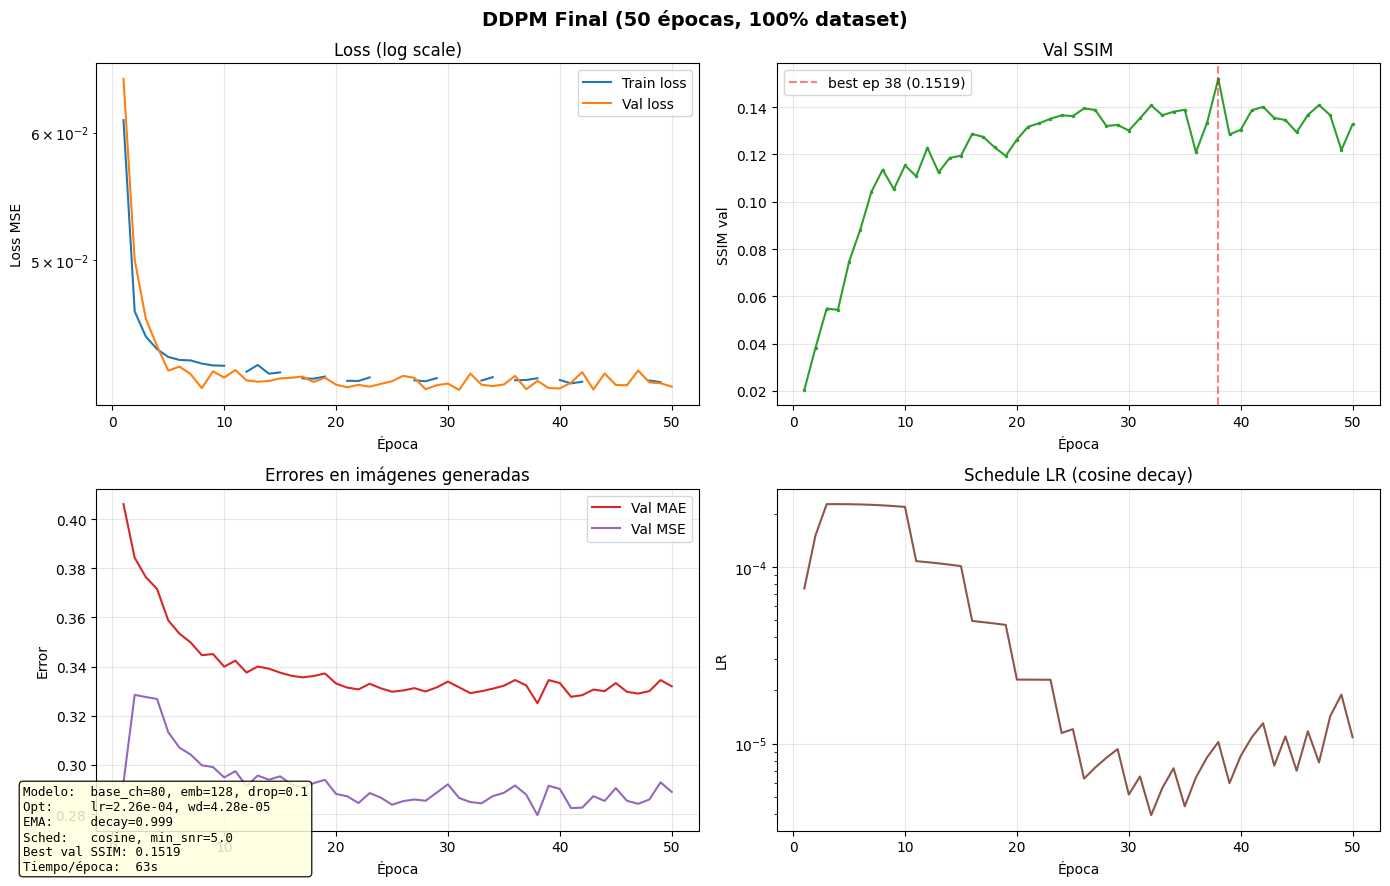

Curvas guardadas en /content/output/ddpm_final_curves.png


In [21]:
hist = final_res['history']
epochs_axis = range(1, len(hist['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"DDPM Final ({FINAL_EPOCHS} épocas, 100% dataset)",
             fontsize=14, fontweight='bold')

# Loss
ax = axes[0, 0]
ax.plot(epochs_axis, hist['train_loss'], label='Train loss', color='tab:blue')
ax.plot(epochs_axis, hist['val_loss'],   label='Val loss',   color='tab:orange')
ax.set_xlabel('Época'); ax.set_ylabel('Loss MSE')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Loss (log scale)')

# SSIM
ax = axes[0, 1]
ax.plot(epochs_axis, hist['val_ssim'], color='tab:green', marker='.', markersize=3)
best_ep = int(np.argmax(hist['val_ssim'])) + 1
ax.axvline(best_ep, color='red', linestyle='--', alpha=0.5,
           label=f'best ep {best_ep} ({max(hist["val_ssim"]):.4f})')
ax.set_xlabel('Época'); ax.set_ylabel('SSIM val'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Val SSIM')

# MAE / MSE
ax = axes[1, 0]
ax.plot(epochs_axis, hist['val_mae'], label='Val MAE', color='tab:red')
ax.plot(epochs_axis, hist['val_mse'], label='Val MSE', color='tab:purple')
ax.set_xlabel('Época'); ax.set_ylabel('Error')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Errores en imágenes generadas')

# Learning rate
ax = axes[1, 1]
ax.plot(epochs_axis, hist['lr'], color='tab:brown')
ax.set_xlabel('Época'); ax.set_ylabel('LR')
ax.set_yscale('log'); ax.grid(alpha=0.3)
ax.set_title('Schedule LR (cosine decay)')

# Caja con info
info_text = (
    f"Modelo:  base_ch={BEST_HPARAMS['base_ch']}, "
    f"emb={BEST_HPARAMS['cond_emb_dim']}, drop={BEST_HPARAMS['dropout']}\n"
    f"Opt:     lr={BEST_HPARAMS['lr']:.2e}, wd={BEST_HPARAMS['weight_decay']:.2e}\n"
    f"EMA:     decay={BEST_HPARAMS['ema_decay']}\n"
    f"Sched:   {BEST_HPARAMS['beta_schedule']}, min_snr={BEST_HPARAMS['min_snr_gamma']}\n"
    f"Best val SSIM: {final_res['best_val_ssim']:.4f}\n"
    f"Tiempo/época:  {np.mean(hist['epoch_time']):.0f}s"
)
fig.text(0.02, 0.02, info_text, va='bottom', fontsize=9, fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.savefig(f"{WORK_DIR}/ddpm_final_curves.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Curvas guardadas en {WORK_DIR}/ddpm_final_curves.png")

## 12. Evaluación final en test set

Cargamos el checkpoint guardado (con pesos EMA) y evaluamos el modelo en el split de **test** (15% del dataset completo).

In [22]:
ckpt = torch.load(CKPT_FINAL, map_location=DEVICE, weights_only=False)
hp   = ckpt['hyperparams']

model_eval = ConditionalUNet(
    img_channels=1,
    base_ch=hp['base_ch'],
    ch_mults=(1, 2, 4),
    cond_dim=COND_DIM,
    emb_dim=hp['cond_emb_dim'],
    dropout=hp['dropout'],
).to(DEVICE)

if ckpt.get('ema') is not None:
    print("Usando pesos EMA para la evaluación final")
    model_eval.load_state_dict(ckpt['model'])
    with torch.no_grad():
        for n, p in model_eval.named_parameters():
            if p.requires_grad and n in ckpt['ema']:
                p.data.copy_(ckpt['ema'][n].to(DEVICE))
else:
    print("Sin EMA — usando pesos online")
    model_eval.load_state_dict(ckpt['model'])

model_eval.eval()

scheduler_eval = DDPMScheduler(
    T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END,
    schedule=hp['beta_schedule'], device=DEVICE,
)

_, _, ds_te, _, _, dl_te = make_dataloaders(SPLIT_FINAL, batch_size=32, num_workers=2)

print(f"\nEvaluando {len(ds_te):,} muestras test "
      f"(fast sampler, {FINAL_VAL_FAST_STEPS} pasos)...")
all_mae, all_mse, all_ssim = [], [], []
t_eval = time.time()
for i, (x0, cond) in enumerate(dl_te):
    x0   = x0.to(DEVICE)
    cond = cond.to(DEVICE)
    x_gen = fast_sample(model_eval, cond, scheduler_eval,
                        n_steps=FINAL_VAL_FAST_STEPS, img_size=IMG_SIZE)
    m, s, ss = compute_metrics(x_gen, x0)
    all_mae.append(m); all_mse.append(s); all_ssim.append(ss)
    if (i + 1) % 10 == 0:
        print(f"  batch {i+1}/{len(dl_te)}  SSIM={ss:.4f}")

eval_min = (time.time() - t_eval) / 60
print(f"\nEvaluación completada en {eval_min:.1f} min")
print(f"\n{'='*64}")
print(f"DDPM FINAL — RESULTADOS TEST (100% dataset)")
print(f"{'='*64}")
print(f"  MAE  test: {np.mean(all_mae):.4f} ± {np.std(all_mae):.4f}")
print(f"  MSE  test: {np.mean(all_mse):.4f} ± {np.std(all_mse):.4f}")
print(f"  SSIM test: {np.mean(all_ssim):.4f} ± {np.std(all_ssim):.4f}")
print(f"{'='*64}")

Usando pesos EMA para la evaluación final

Evaluando 25,451 muestras test (fast sampler, 100 pasos)...
  batch 10/796  SSIM=0.0028
  batch 20/796  SSIM=0.1156
  batch 30/796  SSIM=0.0312
  batch 40/796  SSIM=0.2032
  batch 50/796  SSIM=0.0640
  batch 60/796  SSIM=0.1194
  batch 70/796  SSIM=0.1704
  batch 80/796  SSIM=0.0674
  batch 90/796  SSIM=0.1505
  batch 100/796  SSIM=0.0810
  batch 110/796  SSIM=0.0757
  batch 120/796  SSIM=0.0998
  batch 130/796  SSIM=0.0349
  batch 140/796  SSIM=0.1521
  batch 150/796  SSIM=0.2047
  batch 160/796  SSIM=0.1261
  batch 170/796  SSIM=0.2470
  batch 180/796  SSIM=0.0362
  batch 190/796  SSIM=0.1297
  batch 200/796  SSIM=0.1729
  batch 210/796  SSIM=0.2036
  batch 220/796  SSIM=0.0938
  batch 230/796  SSIM=0.1107
  batch 240/796  SSIM=0.2305
  batch 250/796  SSIM=0.2058
  batch 260/796  SSIM=0.0388
  batch 270/796  SSIM=0.0898
  batch 280/796  SSIM=0.0345
  batch 290/796  SSIM=0.1961
  batch 300/796  SSIM=0.1269
  batch 310/796  SSIM=0.1199
  batch

## 13. Visualización: real vs generado

Cargado EMA state


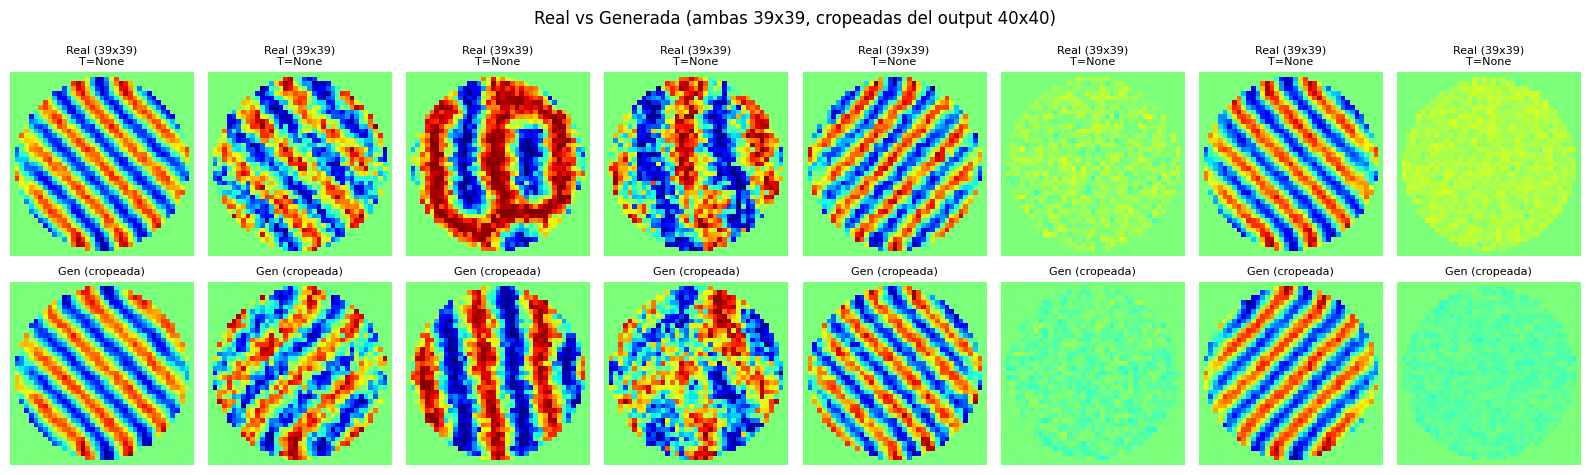

In [23]:
n_show = 8
ds_te = SpinesDataset(SPLIT_FINAL['imgs_te'], SPLIT_FINAL['p_te'], IMG_SIZE)
idx_show = np.random.RandomState(0).choice(len(ds_te), size=n_show, replace=False)

real_imgs, real_cond = [], []
for i in idx_show:
    x, y = ds_te[i]
    real_imgs.append(x); real_cond.append(y)
real_imgs = torch.stack(real_imgs).to(DEVICE)
real_cond = torch.stack(real_cond).to(DEVICE)

# Crear modelo con HPs OPTIMOS y cargar estado del checkpoint final
ckpt = torch.load(CKPT_FINAL, map_location=DEVICE, weights_only=False)
hp = ckpt['hyperparams']

model = ConditionalUNet(
    base_ch=hp['base_ch'], emb_dim=hp['cond_emb_dim'], dropout=hp['dropout'],
).to(DEVICE)

# Cargar EMA si esta disponible
if ckpt['ema'] is not None:
    model.load_state_dict(ckpt['ema'])
    print("Cargado EMA state")
else:
    model.load_state_dict(ckpt['model'])
    print("Cargado model state")

model.eval()

scheduler = DDPMScheduler(
    T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END,
    schedule=hp['beta_schedule'], device=DEVICE,
)

# Generar (output 40x40)
with torch.no_grad():
    gen_imgs_40 = fast_sample(model, real_cond, scheduler, n_steps=100, img_size=IMG_SIZE)

# Crop a 39x39 (esto es lo que veria el Xception)
gen_imgs_39  = gen_imgs_40[:, :, :CROP_TO, :CROP_TO]
real_imgs_39 = real_imgs[:, :, :CROP_TO, :CROP_TO]

fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 5))
for i in range(n_show):
    axes[0, i].imshow(real_imgs_39[i, 0].cpu().numpy(), cmap='jet', vmin=-1, vmax=1)
    axes[0, i].set_title(f"Real (39x39)\nT={ckpt['hyperparams'].get('_', None)}",
                          fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(gen_imgs_39[i, 0].cpu().numpy(), cmap='jet', vmin=-1, vmax=1)
    axes[1, i].set_title("Gen (cropeada)", fontsize=8)
    axes[1, i].axis('off')
fig.suptitle("Real vs Generada (ambas 39x39, cropeadas del output 40x40)")
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/real_vs_gen_39crop.png", dpi=120)
plt.show()


## 14. Guardar métricas finales y descargar artefactos

In [24]:
metrics = {
    'best_val_ssim': float(final_res['best_val_ssim']),
    'last_val_ssim': float(final_res['last_val_ssim']),
    'epochs':        FINAL_EPOCHS,
    'img_size':      IMG_SIZE,
    'crop_to':       CROP_TO,
    'preprocesado':  'pad_reflect',
    'batch_size':    BEST_HPARAMS['batch_size'],
    'lr_final':      BEST_HPARAMS['lr'],
    'subsample':     SUBSAMPLE_FINAL,
    'note': ('DDPM entrenado a 40x40 con pad reflect 39->40. La salida se '
             'cropea a 39x39 (CROP_TO) para coincidir con el tamano del '
             'dataset original que vio el Xception. Esto preserva la textura '
             'fina necesaria para predecir T correctamente.'),
}
import json
with open(METRICS_FINAL, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metricas guardadas en {METRICS_FINAL}")
print(json.dumps(metrics, indent=2))


Metricas guardadas en /content/output/ddpm_final_metrics_39crop.json
{
  "best_val_ssim": 0.1519451211206615,
  "last_val_ssim": 0.13273464748635888,
  "epochs": 50,
  "img_size": 40,
  "crop_to": 39,
  "preprocesado": "pad_reflect",
  "batch_size": 128,
  "lr_final": 0.00022640535194211016,
  "subsample": 1.0,
  "note": "DDPM entrenado a 40x40 con pad reflect 39->40. La salida se cropea a 39x39 (CROP_TO) para coincidir con el tamano del dataset original que vio el Xception. Esto preserva la textura fina necesaria para predecir T correctamente."
}


In [25]:
# Descargar todos los artefactos a tu máquina local
from google.colab import files
import zipfile

zip_path = "/content/ddpm_final_artifacts.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(WORK_DIR):
        zf.write(os.path.join(WORK_DIR, fname), arcname=fname)

print(f"ZIP creado: {zip_path} ({os.path.getsize(zip_path)/1e6:.1f} MB)")
files.download(zip_path)

ZIP creado: /content/ddpm_final_artifacts.zip (401.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. (Opcional) Backup en Google Drive

Si tu sesión de Colab puede caerse, monta Drive y copia los artefactos para no perderlos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, datetime
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
dst = f"/content/drive/MyDrive/ddpm_spines_final_{stamp}"
shutil.copytree(WORK_DIR, dst)
print(f"Copiado a {dst}")

## 16. Sanity test — R²(T) sobre imagenes generadas + cropeadas a 39x39

Genera 200 imagenes con el DDPM nuevo, las cropea al tamano original del dataset, las pasa por el Xception entrenado, y mide R²(T). Objetivo: que R²(T) sea > 0.80 (el Xception alcanza ~0.97 sobre imagenes reales con resize directo 39→224). Si lo logramos, el ciclo invertido completo va a funcionar.

In [ ]:
# =====================================================================
# Sanity test: validar que el DDPM nuevo recupera bien T en el ciclo invertido
# =====================================================================
# Genera 200 imagenes con el DDPM, las cropea a 39x39, las pasa al Xception
# directamente (sin paso intermedio por [mn,mx]-norm), y mide R^2(T).
#
# IMPORTANTE: oculta GPU a TF antes de instanciar Xception para evitar el
# cross-device error que ya conocemos. PyTorch (DDPM) sigue en GPU.

import os, sys, time
import tensorflow as tf

# Ocultar GPU a TF (PyTorch sigue con CUDA)
try:
    tf.config.set_visible_devices([], 'GPU')
    print(">>> TF ahora solo ve CPU. PyTorch sigue con GPU.")
except RuntimeError as e:
    print(f"AVISO: {e}. Si esto es un mensaje de que ya se inicializo TF en GPU,")
    print("reinicia el runtime y corre esta celda como la PRIMERA de TF.")
print(f"TF logical devices: {[d.name for d in tf.config.list_logical_devices()]}")

# ----- Localizar pesos del Xception (Kaggle dataset montado) -----
# IMPORTANTE: ajusta esta ruta a donde tengas el .h5 del Xception en Colab
XCEPTION_INV_WEIGHTS = "/content/kaggle_data/weights-xception-model/modelo_xception_fulldatabaseV3100.h5"
assert os.path.exists(XCEPTION_INV_WEIGHTS), \
    f"No encuentro {XCEPTION_INV_WEIGHTS}. Ajusta la ruta o descarga el dataset."

# ----- Reconstruir Xception y cargar pesos -----
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import (Input, GlobalAveragePooling2D, Dense,
                                     BatchNormalization, Dropout)
from tensorflow.keras.models import Model

def build_xception(n_outputs=8):
    inputs = Input(shape=(224, 224, 3), name="input_layer")
    base = Xception(weights=None, include_top=False, input_tensor=inputs)
    x = GlobalAveragePooling2D(name="global_average_pooling2d")(base.output)
    x = BatchNormalization(name="batch_normalization_4")(x)
    x = Dropout(0.4, name="dropout")(x)
    x = Dense(256, activation="relu", name="dense")(x)
    x = BatchNormalization(name="batch_normalization_5")(x)
    x = Dropout(0.3, name="dropout_1")(x)
    out = Dense(n_outputs, activation="linear", name="dense_1")(x)
    return Model(inputs, out, name="xception_inverso_V3100")

xception_model = build_xception()
xception_model.load_weights(XCEPTION_INV_WEIGHTS)
print(f"Xception cargado en CPU. params={xception_model.count_params():,}")

# ----- Scaler del Xception (mismo seed y split que usaron al entrenarlo) -----
# Estos valores son los del notebook de inversion.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error

INV_SPLIT_SEED       = 42
INV_TEST_FRACTION    = 0.15
INV_VAL_FRACTION_REL = 0.1765
TARGET_HW_INV        = (224, 224)
PARAM_NAMES = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]

# Reconstruir split del Xception (sobre el dataset completo)
all_idx = np.arange(N)
idx_train_pool, idx_test_inv, _, _ = train_test_split(
    all_idx, params, test_size=INV_TEST_FRACTION, random_state=INV_SPLIT_SEED)
idx_train_inv, idx_val_inv, _, _ = train_test_split(
    idx_train_pool, params[idx_train_pool],
    test_size=INV_VAL_FRACTION_REL, random_state=INV_SPLIT_SEED)
scaler_inv = MinMaxScaler().fit(params[idx_train_inv])
print(f"scaler_inv data_max T: {scaler_inv.data_max_[0]}")

# ----- Tomar 200 puntos del test set del Xception y generar -----
N_SANITY = 200
rng = np.random.RandomState(123)
sel = rng.choice(len(idx_test_inv), size=N_SANITY, replace=False)
sel_idx = idx_test_inv[sel]
true_params_phys = params[sel_idx].astype(np.float32)
true_T = true_params_phys[:, 0]

# Necesitamos el scaler_ddpm del entrenamiento ACTUAL (ya esta como SPLIT_FINAL['scaler'])
scaler_ddpm = SPLIT_FINAL['scaler']

# Generar con el DDPM (en chunks para no saturar memoria)
print(f"\nGenerando {N_SANITY} imagenes con DDPM (en GPU)...")
t0 = time.time()
BATCH = 64
gen_imgs_39 = np.empty((N_SANITY, CROP_TO, CROP_TO), dtype=np.float32)
for i0 in range(0, N_SANITY, BATCH):
    i1 = min(i0 + BATCH, N_SANITY)
    cond_norm = scaler_ddpm.transform(true_params_phys[i0:i1]).astype(np.float32)
    cond_t = torch.from_numpy(cond_norm).to(DEVICE)
    with torch.no_grad():
        x_gen_40 = fast_sample(model, cond_t, scheduler, n_steps=100, img_size=IMG_SIZE)
    # Crop a 39x39
    x_gen_39 = x_gen_40[:, :, :CROP_TO, :CROP_TO]
    gen_imgs_39[i0:i1] = x_gen_39[:, 0].cpu().numpy()
print(f"  Generacion: {time.time()-t0:.1f}s")
print(f"  shape={gen_imgs_39.shape}  range=[{gen_imgs_39.min():.3f}, {gen_imgs_39.max():.3f}]")

# ----- Xception sobre las imagenes cropeadas a 39 -----
print(f"\nXception sobre {N_SANITY} imagenes cropeadas (CPU, en chunks)...")
t0 = time.time()
XCEPTION_CHUNK = 32
y_pred_phys = np.empty((N_SANITY, 8), dtype=np.float32)
for i0 in range(0, N_SANITY, XCEPTION_CHUNK):
    i1 = min(i0 + XCEPTION_CHUNK, N_SANITY)
    chunk = gen_imgs_39[i0:i1, ..., None]                     # (B, 39, 39, 1)
    # Resize directo 39 -> 224 (igual que el preproceso de entrenamiento del Xception)
    chunk = tf.image.resize(chunk, TARGET_HW_INV)              # (B, 224, 224, 1)
    chunk = tf.image.grayscale_to_rgb(chunk)                   # (B, 224, 224, 3)
    y_norm = xception_model.predict(chunk, verbose=0)
    y_pred_phys[i0:i1] = scaler_inv.inverse_transform(y_norm)
print(f"  Xception: {time.time()-t0:.1f}s")

# ----- Metricas finales -----
print("\n" + "=" * 60)
print("RESULTADOS DEL SANITY TEST")
print("=" * 60)
print(f"Comparacion R^2 / MAE por parametro:")
print(f"{'param':>6}  {'R^2':>8}  {'MAE':>8}")
for i, name in enumerate(PARAM_NAMES):
    yt = true_params_phys[:, i]; yp = y_pred_phys[:, i]
    r2 = r2_score(yt, yp) if np.var(yt) > 1e-12 else float('nan')
    mae = mean_absolute_error(yt, yp)
    print(f"{name:>6}  {r2:+8.4f}  {mae:8.4f}")

r2_T_final = r2_score(true_T, y_pred_phys[:, 0])
mae_T_final = mean_absolute_error(true_T, y_pred_phys[:, 0])
print()
print(f">>> R^2(T) del DDPM nuevo + crop 39x39: {r2_T_final:+.4f}")
print(f">>> MAE(T): {mae_T_final:.4f}")
print(f">>> Para referencia, R^2(T) del DDPM viejo (40x40 directo): -0.71")
print(f">>> Objetivo: R^2(T) > 0.80 (que es lo que el Xception logra con")
print(f"    imagenes reales).")

if r2_T_final > 0.80:
    print("\n*** EXITO: el reentrenamiento arreglo el problema de T. ***")
elif r2_T_final > 0.50:
    print("\n*** MEJORA SUSTANCIAL pero todavia hay margen. Considerar mas epocas. ***")
else:
    print("\n*** El R^2 sigue bajo. Algo no esta bien -- revisar logs. ***")
